In [ ]:
!kaggle datasets download -d roroyaseen/brain-tumor-data-mri


Dataset URL: https://www.kaggle.com/datasets/roroyaseen/brain-tumor-data-mri
License(s): unknown
100% 1.58G/1.59G [00:42<00:00, 43.5MB/s]
100% 1.59G/1.59G [00:42<00:00, 40.0MB/s]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization,
    Activation, Flatten, Input, Add
)
from tensorflow.keras.regularizers import l2

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import zipfile
import os

# Define the path of your downloaded dataset
zip_file_path = "/content/brain-tumor-data-mri.zip"  # Change the name if needed

# Define the extraction folder
extract_to = "/content/brain-tumor-data-mri"

# Unzip the dataset
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Dataset extracted to {extract_to}")


Dataset extracted to /content/brain-tumor-data-mri


In [ ]:
!unzip '/kaggle/working/brain-tumor-data-mri.zip'

unzip:  cannot find or open /kaggle/working/brain-tumor-data-mri.zip, /kaggle/working/brain-tumor-data-mri.zip.zip or /kaggle/working/brain-tumor-data-mri.zip.ZIP.


In [ ]:
# Path to the extracted dataset folder in Colab
dataset_dir_train = '/content/brain-tumor-data-mri/New folder (6)/train'
dataset_dir_valid = '/content/brain-tumor-data-mri/New folder (6)/val'

# Verifying the paths
import os

print("Train dataset contains:", os.listdir(dataset_dir_train))
print("Validation dataset contains:", os.listdir(dataset_dir_valid))


Train dataset contains: ['Glioma', 'Pituitary tumor', 'Meningioma']
Validation dataset contains: ['Glioma', 'Pituitary tumor', 'Meningioma']


In [ ]:
dataset_dir_train='/kaggle/working/New folder (6)/train'
dataset_dir_valid='/kaggle/working/New folder (6)/val'

In [ ]:
# Data Augmentation for Training Set
train_datagen = ImageDataGenerator(
    rescale=1.0/255,            # Rescale pixel values (0-1)
    rotation_range=20,          # Random rotation
    width_shift_range=0.2,      # Horizontal shift
    height_shift_range=0.2,     # Vertical shift/
    shear_range=0.2,            # Shear transformation
    zoom_range=0.2,             # Random zoom
    horizontal_flip=True,       # Random horizontal flip
    fill_mode='nearest'         # Fill mode for transformations
)

# Validation set (only rescaling, no augmentation)
valid_datagen = ImageDataGenerator(rescale=1.0/255)

In [ ]:
# Load Training Data
train_data = train_datagen.flow_from_directory(
    dataset_dir_train,
    target_size=(224, 224),  # Match EfficientNetB0 input size
    batch_size=32,           # Adjust batch size as needed
    class_mode='categorical' # Use 'categorical' for multi-class classification
)

# Load Validation Data
valid_data = valid_datagen.flow_from_directory(
    dataset_dir_valid,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Display class indices
print("Class Indices:", train_data.class_indices)

Found 18398 images belonging to 3 classes.
Found 828 images belonging to 3 classes.
Class Indices: {'Glioma': 0, 'Meningioma': 1, 'Pituitary tumor': 2}


In [ ]:
img_height, img_width = 224, 224  # Standard input size for EfficientNetB0
batch_size = 32
epochs = 20

In [ ]:


model = Sequential([
    Input(shape=(img_height, img_width, 3)),  # Explicit Input layer

    # First Convolution Block
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Second Convolution Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Third Convolution Block with increased filters
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Fourth Convolution Block with even more filters
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Fifth Convolution Block (Increase depth again)
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Flattening the output
    Flatten(),

    # Fully connected layers with Dropout
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.5),

    # Output layer for 4 classes (softmax activation)
    Dense(3, activation='softmax')  # Adjusted for 4 classes
])

# Model Summary
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 14, 14, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      25,691,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,8

 Total params: 27,790,019 (106.01 MB)

 Trainable params: 27,788,035 (106.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
checkpoint = ModelCheckpoint("mri_best_model.keras", save_best_only=True, monitor="val_accuracy", mode="max")
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


575/575 ━━━━━━━━━━━━━━━━━━━━ 5413s 9s/step - accuracy: 0.4693 - loss: 2.1798 - val_accuracy: 0.6039 - val_loss: 0.8001
Epoch 2/20
280/575 ━━━━━━━━━━━━━━━━━━━━ 45:46 9s/step - accuracy: 0.5447 - loss: 1.0151

In [ ]:
model.evaluate(valid_data)

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('mri_best_model.keras')

# Model summary
model.summary()

# Evaluate the loaded model on validation data
loss, accuracy = model.evaluate(valid_data)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")


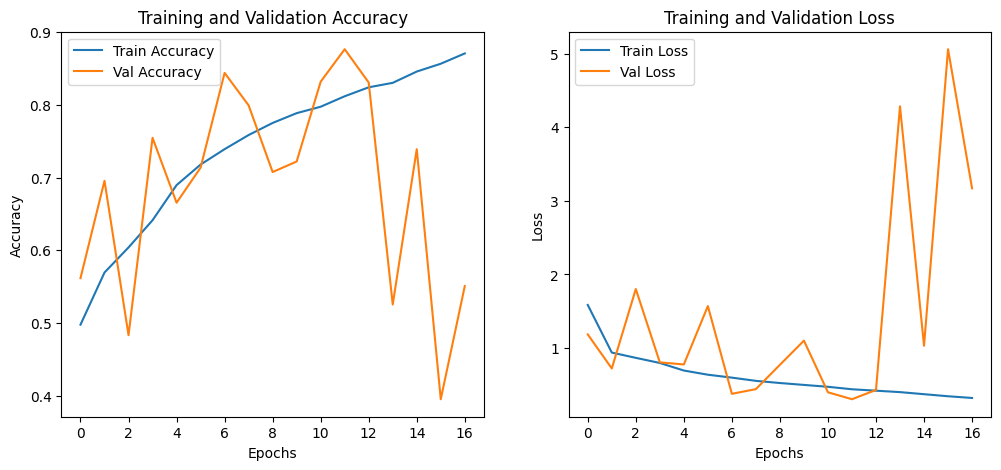

In [ ]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


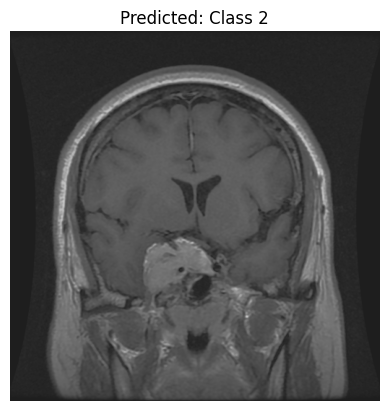

Predicted Class: Class 2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Function to preprocess the input image
def preprocess_image(image_path, img_height, img_width):
    # Load the image with the target size (resizing the image)
    img = image.load_img(image_path, target_size=(img_height, img_width))

    # Convert the image to a numpy array and rescale it
    img_array = image.img_to_array(img) / 255.0  # Rescaling (same as during training)

    # Add batch dimension (model expects input shape to be [batch_size, height, width, channels])
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

# Load the image
image_path = '/kaggle/working/New folder (6)/val/Meningioma/2351.png'  # Replace with your image path
processed_image = preprocess_image(image_path, img_height, img_width)

# Predict the class of the image
prediction = model.predict(processed_image)

# Get the class with the highest probability
predicted_class = np.argmax(prediction, axis=1)[0]  # Get the predicted class index

# Class labels (replace these with your actual class labels)
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']  # Update with actual class names

# Display the image and the predicted class
plt.imshow(image.load_img(image_path))
plt.title(f'Predicted: {class_labels[predicted_class]}')
plt.axis('off')  # Turn off axis
plt.show()

print(f"Predicted Class: {class_labels[predicted_class]}")
